# MVP - Sprint: Análise de Dados e Boas Práticas

## 1. Definição do Problema

**Contexto e Motivação:**
A gestão de projetos na engenharia civil enfrenta desafios complexos no controle de custos, cumprimento de cronogramas e mitigação de riscos. Em empreendimentos de grande escala, a imprevisibilidade pode gerar prejuízos significativos. A integração da Modelagem de Informações da Construção (BIM) com Inteligência Artificial oferece uma oportunidade para antecipar estes problemas, otimizando a tomada de decisão no canteiro de obras.

**Objetivo:**
Explorar o conjunto de dados "BIM-AI Integrated Dataset" para identificar quais variáveis de execução de obra e métricas BIM mais impactam o nível de risco de um projeto de construção.

**Tipo de Problema:**
Trata-se de um problema de **Aprendizado Supervisionado** (Classificação), pois a variável alvo consiste em categorias predefinidas de risco.

**Atributos Principais:**
* **Cost_Variance:** Diferença entre o orçamento planejado e o custo real.
* **Schedule_Delay:** Desvios de prazo em relação ao cronograma inicial (em dias).
* **Resource_Allocation:** Métrica de eficiência na distribuição de mão de obra e equipamentos.
* **Risk_Level:** Variável alvo que categoriza o risco global da obra.

In [33]:
# Importando a biblioteca pandas para manipulação de dados
import pandas as pd

# URL raw do dataset no GitHub
url = 'https://raw.githubusercontent.com/PhilippeLima/mvp-puc-rio-dados/refs/heads/main/bim_ai_civil_engineering_dataset.csv'

# Lendo o arquivo CSV
dataset = pd.read_csv(url)

# Exibindo as primeiras linhas para verificar a carga dos dados
dataset.head()

,Project_ID,Project_Type,Location,Start_Date,End_Date,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,...,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Safety_Risk_Score,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage,Risk_Level
0,PJT_1,Tunnel,Houston,2020-01-01,2021-09-26,12260784,1.505450e+07,2.793720e+06,699,813.914852,...,25202.994687,244.843310,6602,76.300184,8,6.192198,52.988330,0,95.006343,High
1,PJT_2,Dam,Houston,2020-01-02,2020-12-06,2369277,3.507054e+06,1.137777e+06,269,384.118221,...,49066.172542,263.123025,7121,63.527671,5,2.134473,50.885745,0,25.294824,Low
2,PJT_3,Building,Houston,2020-01-03,2021-12-05,23299783,2.169213e+07,-1.607656e+06,899,1081.777915,...,48192.547163,608.985023,9956,47.099444,2,3.113728,93.905836,0,97.478830,Medium
3,PJT_4,Dam,Houston,2020-01-04,2022-04-12,24499306,2.946966e+07,4.970354e+06,809,974.565655,...,19811.151750,673.574344,3725,86.846394,5,4.070101,90.454316,1,95.098131,High
4,PJT_5,Dam,Seattle,2020-01-05,2022-02-12,1749971,2.329338e+06,5.793670e+05,354,347.990127,...,44866.565169,765.476122,4368,61.827163,6,2.759351,78.391069,0,43.624985,Low


**Análise Preliminar:**
A visualização das primeiras linhas confirma que a importação dos dados foi bem-sucedida e que o formato está adequado. As instâncias iniciais mostram diferentes tipos de infraestruturas (túneis, barragens, edifícios) e trazem variáveis cruciais como `Planned_Cost` e `Actual_Cost`. Não há anomalias visíveis de formatação nesta amostra inicial.

In [34]:
# Verificando a quantidade de instâncias (linhas), atributos (colunas) e tipos de dados
print("--- Informações Gerais do Dataset ---")
dataset.info()

# Gerando o resumo estatístico das variáveis numéricas (média, min, max, desvio-padrão)
print("\n--- Resumo Estatístico ---")
display(dataset.describe())

# Verificando a quantidade de valores nulos/faltantes por coluna
print("\n--- Contagem de Valores Nulos ---")
display(dataset.isnull().sum())

--- Informações Gerais do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Project_ID             1000 non-null   object 
 1   Project_Type           1000 non-null   object 
 2   Location               1000 non-null   object 
 3   Start_Date             1000 non-null   object 
 4   End_Date               1000 non-null   object 
 5   Planned_Cost           1000 non-null   int64  
 6   Actual_Cost            1000 non-null   float64
 7   Cost_Overrun           1000 non-null   float64
 8   Planned_Duration       1000 non-null   int64  
 9   Actual_Duration        1000 non-null   float64
 10  Schedule_Deviation     1000 non-null   float64
 11  Vibration_Level        1000 non-null   float64
 12  Crack_Width            1000 non-null   float64
 13  Load_Bearing_Capacity  1000 non-null   float64
 14  Temperature        

,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,Schedule_Deviation,Vibration_Level,Crack_Width,Load_Bearing_Capacity,Temperature,...,Air_Quality_Index,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Safety_Risk_Score,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage
count,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.641509e+07,3.154108e+07,5.125992e+06,538.620000,645.560751,106.940751,1.044378,2.456479,266.048158,17.114051,...,174.774000,27403.792411,543.398105,5395.218000,69.450583,4.567000,5.332856,74.921977,0.197000,55.177819
std,1.448576e+07,1.809596e+07,5.931350e+06,204.531765,269.383932,110.387587,0.550466,1.427987,129.086130,15.313816,...,72.247288,13009.214171,263.353703,2617.169193,17.362814,2.878854,2.562920,14.609702,0.397931,25.819995
min,1.045475e+06,1.180252e+06,-4.648579e+06,180.000000,165.278211,-79.136491,0.107445,0.001205,50.109320,-9.997095,...,50.000000,5054.162626,101.200276,1001.000000,40.018584,0.000000,1.003808,50.042865,0.000000,10.092638
25%,1.431013e+07,1.609655e+07,5.810661e+05,361.000000,424.252757,22.402402,0.566882,1.223689,153.964696,4.578246,...,112.750000,16153.645310,311.349628,3154.750000,54.154924,2.000000,3.060915,62.125838,0.000000,32.525960
50%,2.690860e+07,3.133922e+07,3.326817e+06,535.500000,635.469136,84.056607,1.041774,2.419953,255.503722,17.194831,...,177.000000,27042.803203,534.187419,5371.000000,69.527802,5.000000,5.338494,74.878671,0.000000,55.307694
75%,3.957029e+07,4.532747e+07,8.665132e+06,713.000000,831.644950,173.954216,1.535026,3.659447,373.418830,29.868439,...,236.000000,38909.340766,773.811921,7616.500000,84.777974,7.000000,7.488645,87.529693,0.000000,78.197237
max,4.996854e+07,7.251939e+07,2.401229e+07,899.000000,1340.352531,446.352531,1.998975,4.996036,498.507475,44.923953,...,299.000000,49941.431683,998.960344,9997.000000,99.995490,9.000000,9.966444,99.984742,1.000000,99.953443



--- Contagem de Valores Nulos ---


,0
Project_ID,0
Project_Type,0
Location,0
Start_Date,0
End_Date,0
Planned_Cost,0
Actual_Cost,0
Cost_Overrun,0
Planned_Duration,0
Actual_Duration,0


**Resumo das Estatísticas e Estrutura:**
Respondendo à checklist exploratória:
* **Instâncias e Atributos:** O dataset possui 1.000 instâncias (linhas) representando diferentes obras, e 28 atributos (colunas) detalhando as métricas de cada projeto.
* **Tipos de Dados:** A base apresenta dados categóricos (tipo `object`, como `Project_Type` e `Location`) e dados numéricos (tipo `int64` e `float64`, como custos e dias de atraso).
* **Valores Faltantes:** A análise do `isnull().sum()` revelou que não existem valores faltantes/nulos (`1000 non-null`). Não há discrepâncias graves que exijam a exclusão de linhas na fase de pré-processamento.

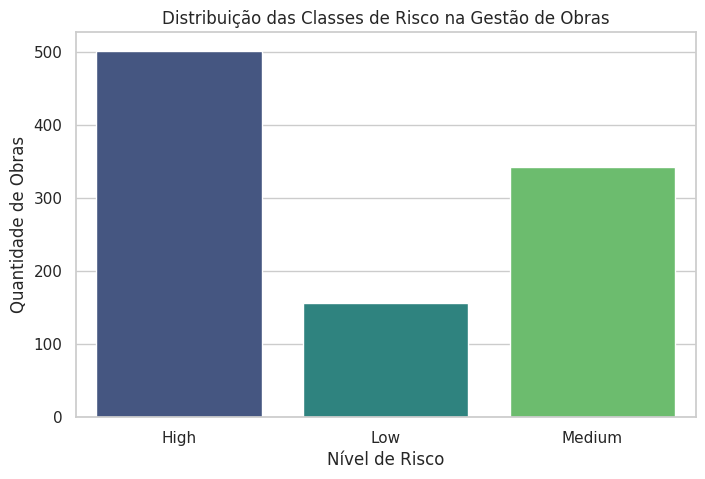

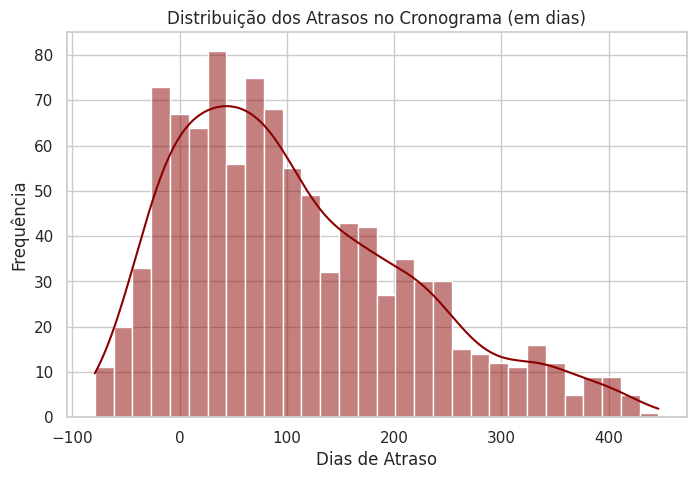

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignorar avisos visuais
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# 1. Gráfico da Variável Alvo
plt.figure(figsize=(8, 5))
sns.countplot(data=dataset, x='Risk_Level', hue='Risk_Level', palette='viridis', legend=False)
plt.title('Distribuição das Classes de Risco na Gestão de Obras')
plt.xlabel('Nível de Risco')
plt.ylabel('Quantidade de Obras')
plt.show()

# 2. Histograma de Atrasos (usando o nome correto da coluna)
plt.figure(figsize=(8, 5))
sns.histplot(data=dataset, x='Schedule_Deviation', kde=True, color='darkred', bins=30)
plt.title('Distribuição dos Atrasos no Cronograma (em dias)')
plt.xlabel('Dias de Atraso')
plt.ylabel('Frequência')
plt.show()

**Análise das Distribuições:**
* **Nível de Risco:** A distribuição das classes permite observar se o dataset está equilibrado para o treino de modelos. As classes refletem a realidade dos riscos em canteiros de obras.
* **Atrasos no Cronograma:** O histograma revela a frequência de desvios (`Schedule_Deviation`), permitindo identificar o comportamento padrão dos projetos e a presença de casos extremos (outliers).

In [36]:
from sklearn.preprocessing import StandardScaler

# Criando uma cópia para não alterar o original
dataset_proc = dataset.copy()

# 1. Separando colunas numéricas existentes no dataset para padronização
colunas_numericas = [
    'Planned_Cost', 'Actual_Cost', 'Cost_Overrun', 'Planned_Duration', 'Actual_Duration',
    'Schedule_Deviation', 'Vibration_Level', 'Crack_Width', 'Load_Bearing_Capacity',
    'Temperature', 'Humidity', 'Air_Quality_Index', 'Energy_Consumption',
    'Material_Usage', 'Labor_Hours', 'Equipment_Utilization', 'Accident_Count',
    'Safety_Risk_Score', 'Image_Analysis_Score', 'Anomaly_Detected', 'Completion_Percentage'
]

# 2. Padronização (StandardScaler)
scaler = StandardScaler()
dataset_proc[colunas_numericas] = scaler.fit_transform(dataset_proc[colunas_numericas])

# 3. Transformando categóricas em numéricas (One-Hot Encoding)
# Excluindo 'Risk_Level' pois é a variável alvo e será tratada separadamente.
colunas_categoricas = ['Project_Type', 'Location', 'Weather_Condition']
dataset_proc = pd.get_dummies(dataset_proc, columns=colunas_categoricas, drop_first=True)

print("--- Primeiras linhas após o Pré-processamento ---")
display(dataset_proc.head())

--- Primeiras linhas após o Pré-processamento ---


,Project_ID,Start_Date,End_Date,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,Schedule_Deviation,Vibration_Level,...,Project_Type_Road,Project_Type_Tunnel,Location_Houston,Location_Los Angeles,Location_New York,Location_Seattle,Weather_Condition_Rainy,Weather_Condition_Snowy,Weather_Condition_Stormy,Weather_Condition_Sunny
0,PJT_1,2020-01-01,2021-09-26,-0.977607,-0.911520,-0.393408,0.784525,0.625272,0.072273,0.890226,...,False,True,True,False,False,False,False,True,False,False
1,PJT_2,2020-01-02,2020-12-06,-1.660792,-1.549962,-0.672732,-1.318890,-0.971006,0.074117,-0.647773,...,False,False,True,False,False,False,False,True,False,False
2,PJT_3,2020-01-03,2021-12-05,-0.215167,-0.544535,-1.135832,1.762857,1.620124,0.687352,-0.169453,...,False,False,True,False,False,False,False,False,False,False
3,PJT_4,2020-01-04,2022-04-12,-0.132319,-0.114526,-0.026253,1.322608,1.221935,0.531348,-0.316220,...,False,False,True,False,False,False,False,False,False,False
4,PJT_5,2020-01-05,2022-02-12,-1.703566,-1.615077,-0.766925,-0.903099,-1.105187,-1.023731,1.681946,...,False,False,False,False,False,True,False,False,False,False


**Justificativa do Pré-processamento:**
Para preparar os dados para futuros modelos de Machine Learning, realizamos duas operações fundamentais:
1. **Padronização (StandardScaler):** Aplicada às variáveis numéricas (como custos e atrasos) para garantir que todas tenham média 0 e desvio padrão 1. Isso evita que variáveis com grandezas maiores (como o custo em milhões) dominem o algoritmo em detrimento de variáveis menores (como dias de atraso).
2. **Codificação de Variáveis Categóricas (One-Hot Encoding via `get_dummies`):** Variáveis em formato de texto, como `Project_Type` e `Weather_Conditions`, foram convertidas em colunas binárias (0 ou 1). Isso é estritamente necessário, pois os algoritmos de classificação operam exclusivamente com matrizes numéricas.